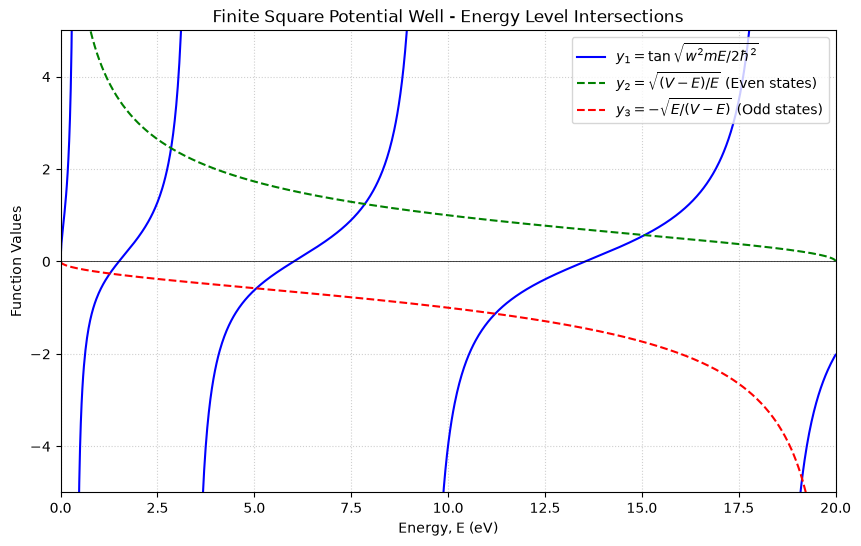

In [1]:
# a
import numpy as np
import pylab as plt

# constants
m = 9.1094e-31
h_bar = 1.0545718e-34
e = 1.602176634e-19

# values
V_ev = 20.0  # well height (eV)
w = 1e-9     # Well width (1nm)
V = V_ev * e # V in Joules

# Energy array E from 0 to 20 eV (in Joules)
E_ev = np.linspace(0.001, 19.999, 1000) # Avoid boundaries to protect denominators
E = E_ev * e

# Calculate functions
arg = np.sqrt((w**2 * m * E) / (2 * h_bar**2))
y1 = np.tan(arg)

y2 = np.sqrt((V_ev - E_ev) / E_ev)
y3 = -np.sqrt(E_ev / (V_ev - E_ev))

# Mask out large values to keep the plot clean near asymptotes
y1[abs(y1) > 10] = np.nan

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(E_ev, y1, label=r'$y_1 = \tan\sqrt{w^2mE/2\hbar^2}$', color='blue', linewidth=1.5)
plt.plot(E_ev, y2, label=r'$y_2 = \sqrt{(V-E)/E}$ (Even states)', color='green', linestyle='--')
plt.plot(E_ev, y3, label=r'$y_3 = -\sqrt{E/(V-E)}$ (Odd states)', color='red', linestyle='--')

# Plot Customization
plt.ylim(-5, 5)
plt.xlim(0, 20)
plt.xlabel('Energy, E (eV)')
plt.ylabel('Function Values')
plt.title('Finite Square Potential Well - Energy Level Intersections')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()

In [ ]:
import numpy as np

# Constants (SI Units)
m = 9.1094e-31       # Mass of electron (kg)
hbar = 1.0545718e-34 # Reduced Planck's constant (J*s)
e = 1.602176634e-19  # Elementary charge (C)

# Given Parameters
V_ev = 20.0          # Well height (eV)
w = 1e-9             # Well width (1 nm)

def f_even(E_ev):
    """Equation to solve for even states: y1 - y2 = 0"""
    E = E_ev * e
    arg = np.sqrt((w**2 * m * E) / (2 * hbar**2))
    return np.tan(arg) - np.sqrt((V_ev - E_ev) / E_ev)

def f_odd(E_ev):
    """Equation to solve for odd states: y1 - y3 = 0"""
    E = E_ev * e
    arg = np.sqrt((w**2 * m * E) / (2 * hbar**2))
    return np.tan(arg) + np.sqrt(E_ev / (V_ev - E_ev))

def binary_search(f, low, high, accuracy=0.001):
    """Binary search routine to find roots within a targeted interval"""
    while (high - low) > accuracy:
        mid = (low + high) / 2.0
        if f(low) * f(mid) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2.0

# Safe search intervals chosen away from tan(x) asymptotes based on our graph:
intervals = [
    (0.1, 0.5, f_even),   # E0 (Even)
    (1.0, 1.5, f_odd),    # E1 (Odd)
    (2.5, 3.2, f_even),   # E2 (Even)
    (4.5, 5.5, f_odd),    # E3 (Odd)
    (7.0, 8.5, f_even),   # E4 (Even)
    (10.5, 12.0, f_odd)   # E5 (Odd)
]

print("Calculated Precise Energy Levels (Accuracy: 0.001 eV):")
print("-" * 55)
for i, (low, high, func) in enumerate(intervals):
    energy = binary_search(func, low, high, tolerance=0.001)
    state_type = "Even" if i % 2 == 0 else "Odd"
    print(f"State {i} ({state_type} - E{i}): {energy:.3f} eV")

Calculated Precise Energy Levels (Accuracy: 0.001 eV):
-------------------------------------------------------
State 0 (Even - E0): 0.500 eV
State 1 (Odd - E1): 1.270 eV
State 2 (Even - E2): 2.851 eV
State 3 (Odd - E3): 5.050 eV
State 4 (Even - E4): 7.850 eV
State 5 (Odd - E5): 11.215 eV
